# **Data Ingestion and Dataset Loading**

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set global plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Locate dataset files under Kaggle input
data_dir = "/kaggle/input"
all_files = glob.glob(os.path.join(data_dir, "**/*"), recursive=True)

# 1. Filter explicitly for primary split files or main GoEmotions partitions
csv_candidates = [
    f for f in all_files 
    if f.endswith(".csv") and any(k in os.path.basename(f) for k in ["goemotions_1", "goemotions_2", "goemotions_3"])
]
tsv_candidates = [
    f for f in all_files 
    if f.endswith(".tsv") and any(k in os.path.basename(f) for k in ["train", "dev", "test"])
]

if csv_candidates:
    # Concatenate standard goemotions_1, goemotions_2, goemotions_3 tables
    dfs = [pd.read_csv(f) for f in sorted(csv_candidates)]
    df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Successfully loaded {len(csv_candidates)} primary CSV partitions.")
elif tsv_candidates:
    # Concatenate standard TSV splits without metadata pollution
    dfs = []
    for f in sorted(tsv_candidates):
        temp_df = pd.read_csv(f, sep="\t", header=None, names=["text", "labels", "id"])
        dfs.append(temp_df)
    df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Successfully loaded {len(tsv_candidates)} primary TSV splits.")
else:
    # Fallback: scan any CSV/TSV containing the actual 'text' column, excluding odds/word files
    valid_files = []
    for f in [x for x in all_files if x.endswith((".csv", ".tsv"))]:
        try:
            sep = "\t" if f.endswith(".tsv") else ","
            header = None if f.endswith(".tsv") else "infer"
            sample = pd.read_csv(f, sep=sep, header=header, nrows=2)
            if "odds" not in sample.columns and "word" not in sample.columns:
                valid_files.append((f, sep, header))
        except Exception:
            continue
            
    if not valid_files:
        raise FileNotFoundError("Could not find raw text data files in /kaggle/input.")
        
    dfs = []
    for f, sep, header in valid_files:
        if header is None:
            temp_df = pd.read_csv(f, sep=sep, header=header, names=["text", "labels", "id"])
        else:
            temp_df = pd.read_csv(f, sep=sep)
        dfs.append(temp_df)
    df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Successfully loaded {len(valid_files)} validated text data files.")

# Clean missing and whitespace-only entries
df = df.dropna(subset=["text"]).reset_index(drop=True)
df["text"] = df["text"].astype(str)
df = df[df["text"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"[INFO] Total clean samples loaded: {len(df):,}")
print(f"[INFO] Dataset Columns: {list(df.columns)}")
df.head(3)

[INFO] Successfully loaded 3 primary CSV partitions.
[INFO] Total clean samples loaded: 211,225
[INFO] Dataset Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1


# **Emotion Taxonomy and Label Anchor Definitions**

In [2]:
from typing import Dict, List
import numpy as np

# 1. Standard 28 GoEmotions emotion taxonomy
GOEMOTIONS_LABELS: List[str] = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]

# 2. Assert all labels exist in the loaded DataFrame columns
missing_cols = [col for col in GOEMOTIONS_LABELS if col not in df.columns]
assert not missing_cols, f"Missing label columns in DataFrame: {missing_cols}"

# 3. Extract multi-hot binary label matrix
label_matrix = df[GOEMOTIONS_LABELS].values.astype(np.float32)

# 4. Canonical anchor definitions for zero-shot text-anchor alignment
GOEMOTIONS_DEFINITIONS: Dict[str, str] = {
    "admiration": (
        "feeling profound respect, wonder, and high esteem toward someone's exceptional "
        "qualities, heroic actions, artistic talent, or impressive accomplishments."
    ),
    "amusement": (
        "finding humor, comedy, or playful wit in a situation; experiencing lighthearted fun, "
        "laughter, chuckling, and entertainment."
    ),
    "anger": (
        "an intense emotional state of rage, fury, hostility, and deep displeasure sparked "
        "by perceived injustice, mistreatment, provocation, or insults."
    ),
    "annoyance": (
        "a mild or moderate feeling of irritation, impatience, and frustration caused by petty "
        "disturbances, persistent nuisances, or inconvenient obstacles."
    ),
    "approval": (
        "expressing positive agreement, endorsement, validation, or formal acceptance of an idea, "
        "decision, proposal, or behavior."
    ),
    "caring": (
        "demonstrating warmth, empathy, affectionate concern, protective kindness, and active "
        "support for the well-being and health of others."
    ),
    "confusion": (
        "a state of bewilderment, cognitive disorientation, or lack of clarity when something is "
        "unclear, contradictory, illogical, or impossible to comprehend."
    ),
    "curiosity": (
        "an eager, inquisitive desire to investigate, explore, ask questions, and acquire new "
        "knowledge or discover hidden information."
    ),
    "desire": (
        "a strong craving, yearning, longing, or passionate impulse to obtain, experience, or possess "
        "a specific object, outcome, or person."
    ),
    "disappointment": (
        "a disheartened, sorrowful feeling resulting from unfulfilled expectations, broken promises, "
        "lost hopes, or disappointing outcomes."
    ),
    "disapproval": (
        "a critical, unfavorable judgment or moral condemnation expressing strong objection to an "
        "action, standard, opinion, or conduct."
    ),
    "disgust": (
        "a visceral sensation of revulsion, profound physical or moral repulsion, nausea, and deep "
        "distaste for something foul, vile, or offensive."
    ),
    "embarrassment": (
        "a painful feeling of self-consciousness, awkwardness, humiliation, or shame caused by an "
        "inappropriate blunder, slip-up, or public faux pas."
    ),
    "excitement": (
        "a vibrant surge of energetic enthusiasm, thrilling anticipation, joyful restlessness, "
        "and eagerness about an upcoming or ongoing exhilarating event."
    ),
    "fear": (
        "a distressing, protective emotional response triggered by impending danger, physical threat, "
        "terror, horrifying situations, or peril."
    ),
    "gratitude": (
        "a heartfelt feeling of thankfulness, appreciation, and indebtedness toward someone who has "
        "provided kindness, favor, guidance, or assistance."
    ),
    "grief": (
        "overwhelming, poignant agony, heartbreak, and profound mourning experienced after a severe "
        "loss, bereavement, or the death of a loved one."
    ),
    "joy": (
        "a bright, radiant sensation of immense happiness, elation, cheerful delight, and inner "
        "satisfaction with life."
    ),
    "love": (
        "a profound, enduring feeling of deep affection, emotional devotion, tender warmth, and "
        "unconditional attachment toward another."
    ),
    "nervousness": (
        "a state of uneasy agitation, nervous apprehension, stage fright, dread, and tension "
        "concerning an uncertain, critical future event."
    ),
    "optimism": (
        "a confident, encouraging mindset characterized by positive hopefulness, cheerfulness, "
        "and expecting favorable, bright outcomes for the future."
    ),
    "pride": (
        "a deep sense of honorable fulfillment and dignity derived from one's own admirable achievements, "
        "ethical actions, or the success of one's group or family."
    ),
    "realization": (
        "a sudden cognitive awakening or epiphany where a previously hidden fact, truth, mistake, "
        "or understanding becomes clearly evident and understood."
    ),
    "relief": (
        "a comforting, peaceful release from intense emotional distress, fear, anxiety, or pain "
        "after a threatening or painful ordeal has passed safely."
    ),
    "remorse": (
        "a painful, self-reproachful pang of guilt, deep moral regret, and sorrow for having wronged, "
        "hurt, or failed someone by one's own actions."
    ),
    "sadness": (
        "a heavy mood of sorrow, dejection, melancholy, weeping, and low spirits resulting from hardship, "
        "loneliness, or bad circumstances."
    ),
    "surprise": (
        "a momentary state of astonishment, shock, bewilderment, or wonder caused by an entirely unexpected, "
        "abrupt, or sudden event."
    ),
    "neutral": (
        "a completely objective, factual, dispassionate tone showing no discernible emotion, sentiment, "
        "or affective bias; purely matter-of-fact."
    ),
}

# 5. Assert 1-to-1 parity between label keys and definition keys
assert set(GOEMOTIONS_LABELS) == set(GOEMOTIONS_DEFINITIONS.keys()), "Mismatch between labels and definitions"

print(f"[INFO] Validated {len(GOEMOTIONS_LABELS)} emotion classes.")
print(f"[INFO] Label matrix successfully created with shape: {label_matrix.shape}")

[INFO] Validated 28 emotion classes.
[INFO] Label matrix successfully created with shape: (211225, 28)


# **Class Imbalance Analysis and Long-Tail Frequency Distribution**

       CLASS IMBALANCE METRICS
Head Class (Dominant):     neutral (55,298 samples)
Tail Class (Sparsest):     grief (673 samples)
Imbalance Ratio:           82.17 : 1


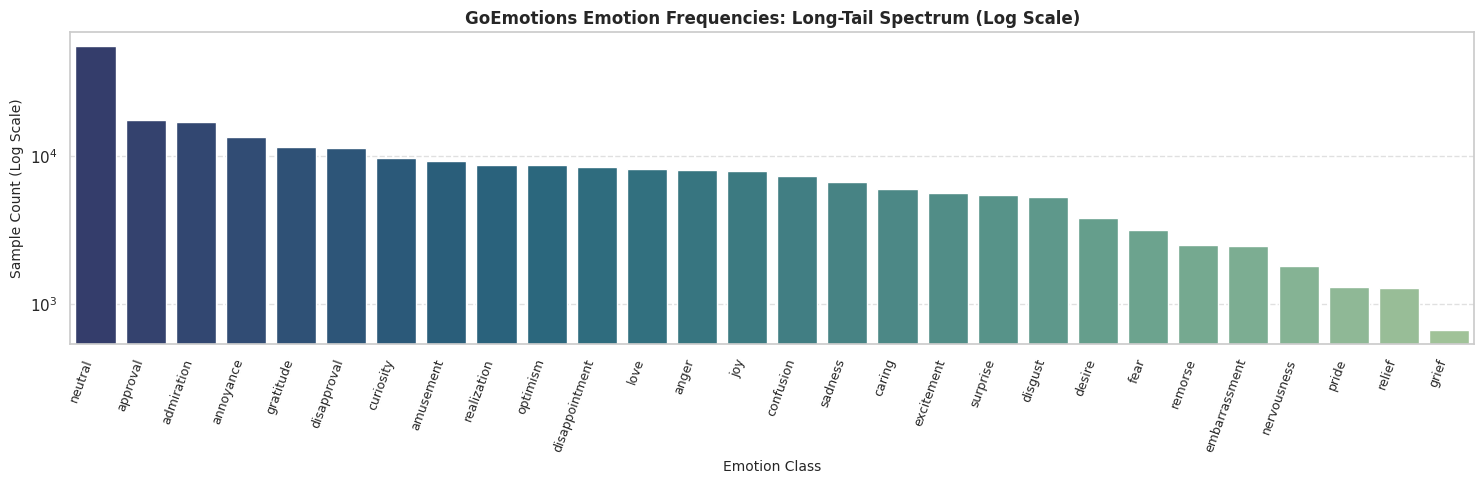

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Verification of matrix structure
assert label_matrix.shape[1] == len(GOEMOTIONS_LABELS), "Dimension mismatch between labels and matrix"

# 2. Compute emotion occurrences and sort descending
frequencies = pd.Series(
    label_matrix.sum(axis=0), index=GOEMOTIONS_LABELS
).sort_values(ascending=False)
imbalance_ratio = frequencies.max() / frequencies.min()

print("=" * 45)
print("       CLASS IMBALANCE METRICS")
print("=" * 45)
print(
    f"Head Class (Dominant):     {frequencies.index[0]} ({int(frequencies.iloc[0]):,} samples)"
)
print(
    f"Tail Class (Sparsest):     {frequencies.index[-1]} ({int(frequencies.iloc[-1]):,} samples)"
)
print(f"Imbalance Ratio:           {imbalance_ratio:.2f} : 1")
print("=" * 45)

# 3. Plot frequency on log scale to highlight the extreme long-tail
plt.figure(figsize=(15, 5))
palette = sns.color_palette("crest_r", len(frequencies))

sns.barplot(
    x=frequencies.index,
    y=frequencies.values,
    hue=frequencies.index,
    palette=palette,
    legend=False,
)

plt.yscale("log")
plt.xticks(rotation=70, ha="right", fontsize=9)
plt.title(
    "GoEmotions Emotion Frequencies: Long-Tail Spectrum (Log Scale)",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Emotion Class", fontsize=10)
plt.ylabel("Sample Count (Log Scale)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

# **Inter-Label Pearson Correlation Analysis and Heatmap**

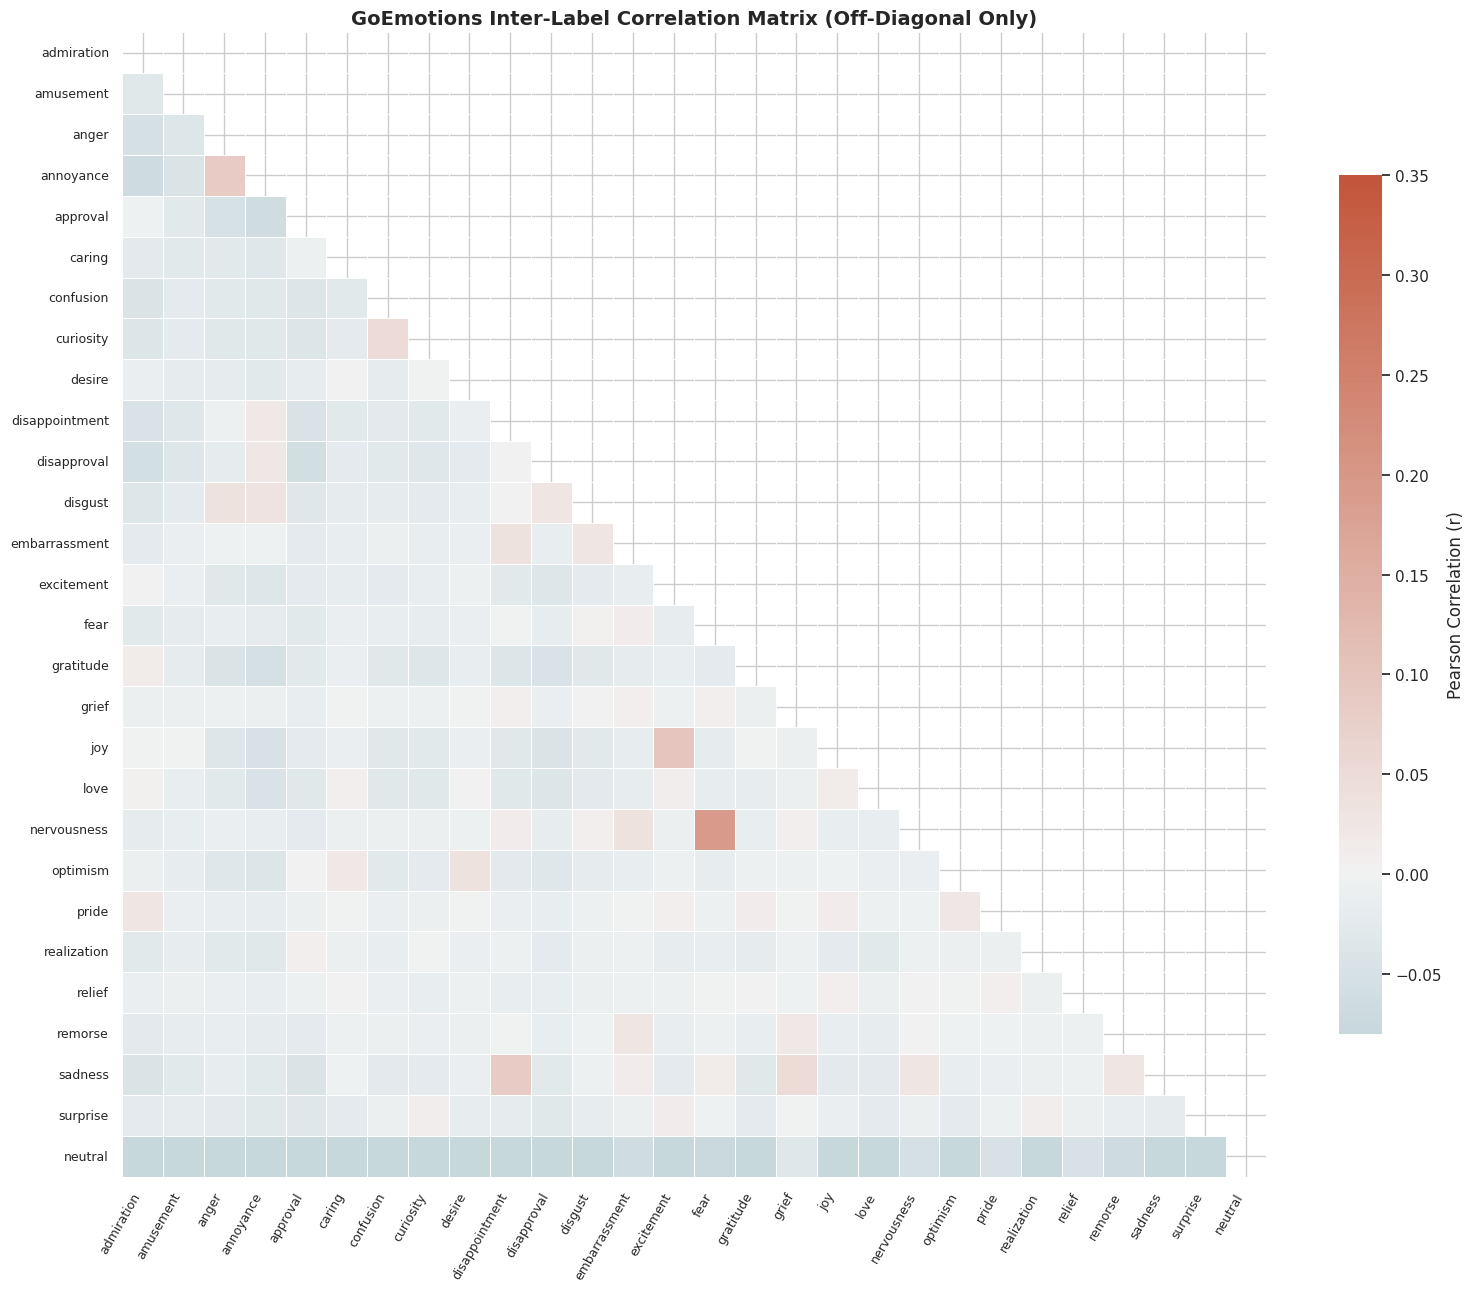

Top 10 Positively Correlated Emotion Pairs
    Emotion_A      Emotion_B  Correlation
  nervousness           fear     0.195458
          joy     excitement     0.101160
    annoyance          anger     0.087398
      sadness disappointment     0.087218
    curiosity      confusion     0.051372
      sadness          grief     0.051300
     optimism         desire     0.035473
embarrassment disappointment     0.035364
  nervousness  embarrassment     0.034256
      disgust          anger     0.032676

Top 5 Negatively Correlated Emotion Pairs
Emotion_A   Emotion_B  Correlation
  neutral    approval    -0.179655
  neutral  admiration    -0.176921
  neutral   annoyance    -0.156333
  neutral   gratitude    -0.143718
  neutral disapproval    -0.142398


In [4]:
# 1. Compute pairwise Pearson correlation matrix
df_labels = pd.DataFrame(label_matrix, columns=GOEMOTIONS_LABELS)
corr_matrix = df_labels.corr(method="pearson")

# 2. Mask diagonal self-correlations (1.0) and upper triangle
np.fill_diagonal(corr_matrix.values, np.nan)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Configure plot dimensions and diverging color palette
plt.figure(figsize=(16, 13))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# 4. Render heatmap with off-diagonal data
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=0.35,
    vmin=-0.08,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation (r)"},
)

plt.title(
    "GoEmotions Inter-Label Correlation Matrix (Off-Diagonal Only)",
    fontsize=14,
    weight="bold",
)
plt.xticks(rotation=60, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

# 5. Extract and rank top co-occurring label pairs
corr_unstacked = corr_matrix.where(~mask).stack().reset_index()
corr_unstacked.columns = ["Emotion_A", "Emotion_B", "Correlation"]

top_positive = corr_unstacked.sort_values(
    by="Correlation", ascending=False
).head(10)
top_negative = corr_unstacked.sort_values(
    by="Correlation", ascending=True
).head(5)

print("=" * 55)
print("Top 10 Positively Correlated Emotion Pairs")
print("=" * 55)
print(top_positive.to_string(index=False))

print("\n" + "=" * 55)
print("Top 5 Negatively Correlated Emotion Pairs")
print("=" * 55)
print(top_negative.to_string(index=False))

# **Label Cardinality Analysis and Multi-Label Distribution**

       MULTI-LABEL CHARACTERISTICS
Mean Label Cardinality:           1.181
Standard Deviation:               0.499
Multi-label Samples (> 1 label):   17.04%
Single-label Samples (= 1 label):  81.34%
Neutral / Unlabeled (= 0 labels):  1.61%
Max Co-occurring Labels:          12


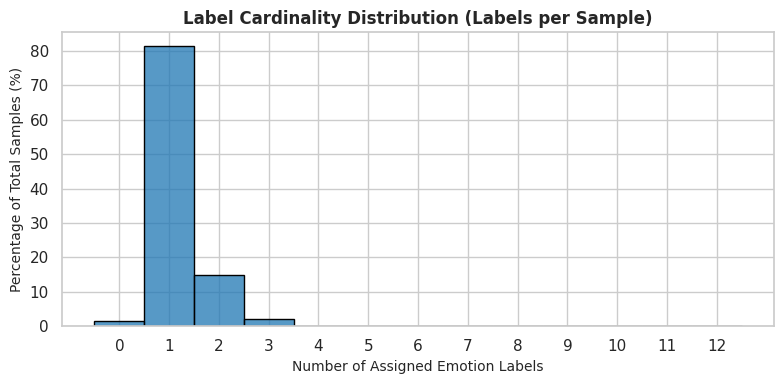

In [5]:
# 1. Compute label count (cardinality) per sample directly from existing label_matrix
cardinality = label_matrix.sum(axis=1)

print("=" * 45)
print("       MULTI-LABEL CHARACTERISTICS")
print("=" * 45)
print(f"Mean Label Cardinality:           {cardinality.mean():.3f}")
print(f"Standard Deviation:               {cardinality.std():.3f}")
print(f"Multi-label Samples (> 1 label):   {(cardinality > 1).mean() * 100:.2f}%")
print(f"Single-label Samples (= 1 label):  {(cardinality == 1).mean() * 100:.2f}%")
print(f"Neutral / Unlabeled (= 0 labels):  {(cardinality == 0).mean() * 100:.2f}%")
print(f"Max Co-occurring Labels:          {int(cardinality.max())}")
print("=" * 45)

# 2. Plot label cardinality distribution
plt.figure(figsize=(8, 4))
bins = np.arange(cardinality.min(), cardinality.max() + 2) - 0.5
sns.histplot(
    cardinality,
    bins=bins,
    discrete=True,
    color="#1f77b4",
    stat="percent",
    edgecolor="black",
)
plt.title("Label Cardinality Distribution (Labels per Sample)", fontsize=12, weight="bold")
plt.xlabel("Number of Assigned Emotion Labels", fontsize=10)
plt.ylabel("Percentage of Total Samples (%)", fontsize=10)
plt.xticks(range(int(cardinality.max()) + 1))
plt.tight_layout()
plt.show()
plt.close()

# **Comprehensive Emotion Frequency and Prevalence Distribution Table**

In [6]:
# 1. Create complete frequency distribution table across all 28 classes
distribution_df = pd.DataFrame(
    {
        "Emotion": frequencies.index,
        "Sample_Count": frequencies.values.astype(int),
        "Percentage (%)": np.round((frequencies.values / len(df)) * 100, 2),
    }
)

# 2. Display the full spectrum from head to tail with temporary formatting
pd.set_option("display.max_rows", 30)
display(distribution_df)
pd.reset_option("display.max_rows")

# 3. Print overall label assignment summary
print(
    f"Total label assignments across all categories: {distribution_df['Sample_Count'].sum():,}"
)

,Emotion,Sample_Count,Percentage (%)
0,neutral,55298,26.18
1,approval,17620,8.34
2,admiration,17131,8.11
3,annoyance,13618,6.45
4,gratitude,11625,5.50
5,disapproval,11424,5.41
6,curiosity,9692,4.59
7,amusement,9245,4.38
8,realization,8785,4.16
9,optimism,8715,4.13


Total label assignments across all categories: 249,529


# **Sequence Length Distribution Analysis and Max-Length Validation**

         SEQUENCE LENGTH EDA
Average Sentence Length:    13.00 words
Median Sentence Length:     13.0 words
95th Percentile:            24.0 words
99th Percentile:            27.0 words
Maximum Sentence Length:    33 words


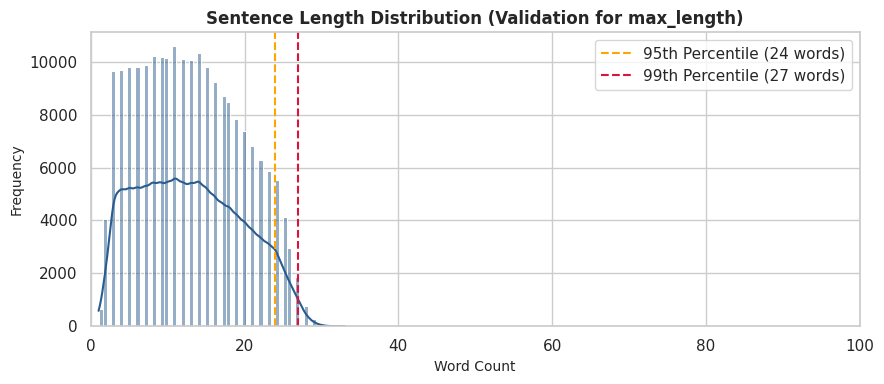

In [7]:
# 1. Compute sequence length by raw word count across active samples
word_counts = df["text"].apply(lambda s: len(s.split()))

# 2. Extract statistical metrics and percentiles
p95 = np.percentile(word_counts, 95)
p99 = np.percentile(word_counts, 99)

print("=" * 45)
print("         SEQUENCE LENGTH EDA")
print("=" * 45)
print(f"Average Sentence Length:    {word_counts.mean():.2f} words")
print(f"Median Sentence Length:     {word_counts.median():.1f} words")
print(f"95th Percentile:            {p95:.1f} words")
print(f"99th Percentile:            {p99:.1f} words")
print(f"Maximum Sentence Length:    {word_counts.max()} words")
print("=" * 45)

# 3. Plot word count distribution with percentile markers
plt.figure(figsize=(9, 4))
sns.histplot(word_counts, bins=60, kde=True, color="#2b5c8f", edgecolor=None)
plt.axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"95th Percentile ({p95:.0f} words)")
plt.axvline(p99, color="crimson", linestyle="--", linewidth=1.5, label=f"99th Percentile ({p99:.0f} words)")
plt.title("Sentence Length Distribution (Validation for max_length)", fontsize=12, weight="bold")
plt.xlabel("Word Count", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.xlim(0, 100)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
plt.close()

# **Emotion Co-Occurrence Matrix Computation and Top Pair Ranking**

In [8]:
# 1. Compute empirical co-occurrence frequency matrix via inner product
co_matrix = label_matrix.T @ label_matrix
np.fill_diagonal(co_matrix, 0)

# 2. Extract upper triangle pairs to avoid duplicate bidirectional counting
pairs = []
num_labels = len(GOEMOTIONS_LABELS)
for i in range(num_labels):
    for j in range(i + 1, num_labels):
        if co_matrix[i, j] > 0:
            pairs.append({
                "Emotion_A": GOEMOTIONS_LABELS[i],
                "Emotion_B": GOEMOTIONS_LABELS[j],
                "Co_occurrences": int(co_matrix[i, j])
            })

# 3. Sort pairs by frequency descending and display top 15
df_pairs = pd.DataFrame(pairs).sort_values(by="Co_occurrences", ascending=False).reset_index(drop=True)

print("=== Top 15 Emotion Pairs that Co-occur in GoEmotions ===")
display(df_pairs.head(15))

=== Top 15 Emotion Pairs that Co-occur in GoEmotions ===


,Emotion_A,Emotion_B,Co_occurrences
0,anger,annoyance,1391
1,admiration,approval,1366
2,admiration,gratitude,1165
3,annoyance,disapproval,1039
4,disappointment,sadness,907
5,excitement,joy,869
6,approval,realization,829
7,annoyance,disappointment,754
8,confusion,curiosity,754
9,approval,optimism,748


# **High-Cardinality Emotion Multi-Label Inspection**

In [9]:
# 1. Filter high-cardinality samples (>= 4 assigned labels) using existing cardinality
high_cardinality_mask = cardinality >= 4
high_card_df = df[high_cardinality_mask].copy()

print(f"Total samples with >= 4 labels: {len(high_card_df):,} ({len(high_card_df)/len(df)*100:.3f}% of dataset)\n")

# 2. Sample and display representative instances with fixed seed for reproducibility
np.random.seed(42)
sample_indices = np.random.choice(len(high_card_df), min(5, len(high_card_df)), replace=False)

for idx in sample_indices:
    row = high_card_df.iloc[idx]
    assigned_labels = [label for label in GOEMOTIONS_LABELS if row[label] == 1.0]
    print(f"Sentence: \"{row['text']}\"")
    print(f"Assigned Emotions ({len(assigned_labels)}): {assigned_labels}")
    print("-" * 70)

Total samples with >= 4 labels: 589 (0.279% of dataset)

Sentence: "Please no hate it’s my first post bro please"
Assigned Emotions (5): ['anger', 'disappointment', 'fear', 'remorse', 'sadness']
----------------------------------------------------------------------
Sentence: "It was a bad one, and you should feel bad. "
Assigned Emotions (4): ['disappointment', 'disapproval', 'disgust', 'sadness']
----------------------------------------------------------------------
Sentence: "That was awesome. Momentum is really something isn't it?"
Assigned Emotions (5): ['admiration', 'confusion', 'curiosity', 'excitement', 'joy']
----------------------------------------------------------------------
Sentence: "Thanks I needed that."
Assigned Emotions (4): ['approval', 'gratitude', 'joy', 'realization']
----------------------------------------------------------------------
Sentence: "Oi he got stabbed in the eye"
Assigned Emotions (5): ['anger', 'disgust', 'embarrassment', 'fear', 'sadness']
------

# **Emotion Isolation Index and Co-Dependency Spectrum Analysis**

In [10]:
# 1. Filter single-label instances and compute occurrence distributions
solo_mask = (cardinality == 1)
solo_counts = label_matrix[solo_mask].sum(axis=0)
total_counts = label_matrix.sum(axis=0)

# 2. Build isolation and co-dependency spectrum table
isolation_df = pd.DataFrame({
    "Emotion": GOEMOTIONS_LABELS,
    "Total_Count": total_counts.astype(int),
    "Solo_Count": solo_counts.astype(int),
    "Solo_Ratio (%)": np.round((solo_counts / total_counts) * 100, 2),
    "Co_occurring_Ratio (%)": np.round(((total_counts - solo_counts) / total_counts) * 100, 2)
}).sort_values(by="Solo_Ratio (%)", ascending=False).reset_index(drop=True)

# 3. Display full spectrum for all 28 classes
pd.set_option("display.max_rows", 30)
print("=== Emotion Isolation & Co-dependency Spectrum ===")
display(isolation_df)
pd.reset_option("display.max_rows")

=== Emotion Isolation & Co-dependency Spectrum ===


,Emotion,Total_Count,Solo_Count,Solo_Ratio (%),Co_occurring_Ratio (%)
0,neutral,55298,55298,100.000000,0.000000
1,disapproval,11424,7686,67.279999,32.720001
2,confusion,7359,4938,67.099998,32.900002
3,amusement,9245,6130,66.309998,33.689999
4,anger,8084,5202,64.349998,35.650002
5,approval,17620,11259,63.900002,36.099998
6,surprise,5514,3472,62.970001,37.029999
7,admiration,17131,10531,61.470001,38.529999
8,annoyance,13618,8342,61.259998,38.740002
9,relief,1289,788,61.130001,38.869999


# **Ekman Higher-Level Emotion Cluster Distribution**

       EKMAN MACRO-EMOTION PREVALENCE
Joy         : 63,690 samples (30.15%)
Neutral     : 55,298 samples (26.18%)
Anger       : 30,473 samples (14.43%)
Surprise    : 29,282 samples (13.86%)
Sadness     : 17,050 samples (8.07%)
Disgust     : 5,301 samples (2.51%)
Fear        : 4,515 samples (2.14%)


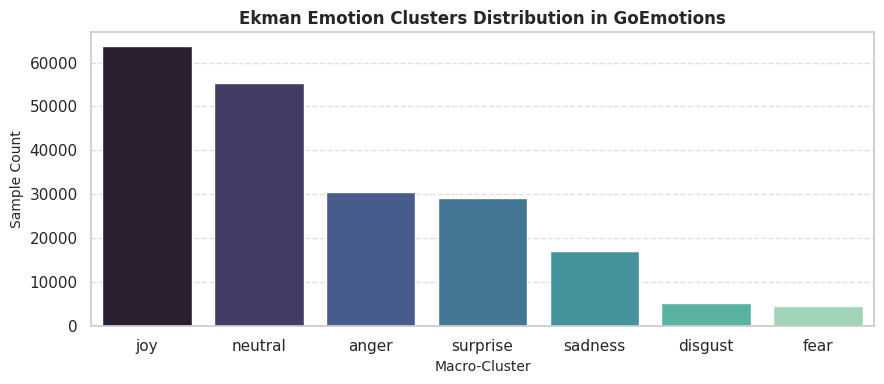

In [11]:
# 1. Map 28 fine-grained GoEmotions labels into Ekman macro-clusters
EKMAN_MAPPING = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["joy", "amusement", "approval", "excitement", "gratitude", "love", "optimism", "pride", "relief"],
    "sadness": ["sadness", "disappointment", "grief", "remorse"],
    "surprise": ["surprise", "curiosity", "confusion", "realization"],
    "neutral": ["neutral"]
}

# 2. Aggregate sample counts per macro-emotion cluster
ekman_counts = {}
for cluster, emos in EKMAN_MAPPING.items():
    cluster_mask = df[emos].sum(axis=1) > 0
    ekman_counts[cluster] = int(cluster_mask.sum())

df_ekman = pd.Series(ekman_counts).sort_values(ascending=False)

print("=" * 50)
print("       EKMAN MACRO-EMOTION PREVALENCE")
print("=" * 50)
for cluster, count in df_ekman.items():
    print(f"{cluster.capitalize():<12}: {count:,} samples ({count/len(df)*100:.2f}%)")
print("=" * 50)

# 3. Barplot of macro-clusters
plt.figure(figsize=(9, 4))
sns.barplot(x=df_ekman.index, y=df_ekman.values, palette="mako", hue=df_ekman.index, legend=False)
plt.title("Ekman Emotion Clusters Distribution in GoEmotions", fontsize=12, weight="bold")
plt.xlabel("Macro-Cluster", fontsize=10)
plt.ylabel("Sample Count", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

# **Correlation Between Sentence Length and Emotion Multi-Label Density**

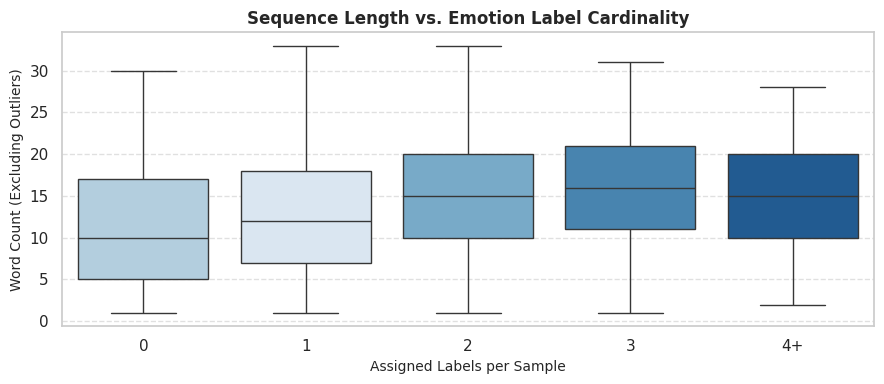

=== Mean Sequence Length per Cardinality Tier ===


,mean,median,std
cardinality_tier,,,
0,11.442685,10.0,7.077981
1,12.639635,12.0,6.655135
2,14.675057,15.0,6.411639
3,16.080844,16.0,6.260404
4+,15.378608,15.0,6.485537


In [12]:
# 1. Group sequence word count by cardinality tiers
df_eda = pd.DataFrame({
    "word_count": word_counts,
    "cardinality": cardinality
})

# Cap cardinality at 4+ for stable statistical boxplot aggregation
df_eda["cardinality_tier"] = df_eda["cardinality"].apply(lambda c: "4+" if c >= 4 else str(int(c)))

# 2. Visual comparison using Boxplot
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=df_eda,
    x="cardinality_tier",
    y="word_count",
    order=["0", "1", "2", "3", "4+"],
    palette="Blues",
    hue="cardinality_tier",
    showfliers=False,
    legend=False
)
plt.title("Sequence Length vs. Emotion Label Cardinality", fontsize=12, weight="bold")
plt.xlabel("Assigned Labels per Sample", fontsize=10)
plt.ylabel("Word Count (Excluding Outliers)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

# 3. Quantitative summary table
length_card_summary = df_eda.groupby("cardinality_tier")["word_count"].agg(["mean", "median", "std"]).loc[["0", "1", "2", "3", "4+"]]
print("=== Mean Sequence Length per Cardinality Tier ===")
display(length_card_summary)

# **Comprehensive Text Preprocessing and Noise Cleaning Pipeline**

In [13]:
import html
import re

# 1. Expanded offline English contraction mappings
CONTRACTION_MAP = {
    r"\bcan't\b": "can not",
    r"\bcannot\b": "can not",
    r"\bwon't\b": "will not",
    r"\bshan't\b": "shall not",
    r"\bain't\b": "is not",
    r"\by'all\b": "you all",
    r"\bgonna\b": "going to",
    r"\bwanna\b": "want to",
    r"\bgimme\b": "give me",
    r"\bn't\b": " not",
    r"\b've\b": " have",
    r"\b're\b": " are",
    r"\b'd\b": " would",
    r"\b'll\b": " will",
    r"\bi'm\b": "i am",
    r"\bhe's\b": "he is",
    r"\bshe's\b": "she is",
    r"\bit's\b": "it is",
    r"\bthat's\b": "that is",
    r"\bwhat's\b": "what is",
    r"\bwhere's\b": "where is",
    r"\bthere's\b": "there is",
    r"\blet's\b": "let us",
}

def expand_all_contractions(text: str) -> str:
    for pattern, replacement in CONTRACTION_MAP.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text

def complete_reddit_preprocessing(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Strip zero-width spaces and non-printable control characters
    text = re.sub(r"[\u200b\u200c\u200d\u200e\u200f\ufeff]", "", text)

    # Decode HTML entities and replace non-breaking spaces
    text = html.unescape(text)
    text = text.replace("&nbsp;", " ")

    # Strip Reddit quote blocks and horizontal dividers
    text = re.sub(r"(?m)^\s*>+.*$", "", text)
    text = re.sub(r"(?m)^[-*_]{3,}\s*$", "", text)

    # Strip Markdown hyperlinks syntax [text](url) -> preserve text
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)

    # Remove URL variants and email formats
    text = re.sub(r"(https?://\S+|www\.\S+|\b[A-Za-z0-9._%+-]+@\S+\b)", "", text)
    text = re.sub(r"\b\S+\.(com|org|net|gov|edu|io|co|me)\S*", "", text)

    # Remove Reddit subreddit and user mentions
    text = re.sub(r"/?([ru])/[A-Za-z0-9_-]+", "", text)

    # Normalize GoEmotions entity placeholders
    text = re.sub(r"\[NAME\]", "someone", text)
    text = re.sub(r"\[RELIGION\]", "religion", text)

    # Expand colloquial contractions natively
    text = expand_all_contractions(text)

    # Compress character repetitions to maximum 2 (e.g. "sooooo" -> "soo")
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1\1", text)

    # Compress excessive punctuation runs to max 2 while preserving emotion cues (? / !)
    text = re.sub(r"\?{2,}", "??", text)
    text = re.sub(r"!{2,}", "!!", text)
    text = re.sub(r"\.{2,}", "..", text)

    # Normalize whitespace while preserving native Unicode emojis for tokenizer
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 2. Execute cleaning pipeline
print("[INFO] Applying text cleaning pipeline...")
initial_count = len(df)
df["cleaned_text"] = df["text"].apply(complete_reddit_preprocessing)

# 3. Filter empty texts and purely non-alphanumeric noise
df = df[df["cleaned_text"].str.strip().str.len() > 0].copy()
df = df[df["cleaned_text"].str.contains(r"[a-zA-Z0-9]", regex=True)].reset_index(drop=True)

# 4. Exact-match deduplication with multi-label aggregation via logical OR (maximum)
aggregated_labels = df.groupby("cleaned_text")[GOEMOTIONS_LABELS].max()
unique_texts = df[["cleaned_text"]].drop_duplicates(subset=["cleaned_text"]).set_index("cleaned_text")
df = unique_texts.join(aggregated_labels).reset_index()

# 5. Synchronize label matrix with deduplicated dataset
label_matrix = df[GOEMOTIONS_LABELS].values.astype(float)
final_count = len(df)

print(f"[SUCCESS] Filtered & Deduplicated: {initial_count - final_count:,} duplicate/noisy rows.")
print(f"[SUCCESS] Final clean dataset size: {final_count:,} samples.")
print(f"[SUCCESS] Synchronized label_matrix shape: {label_matrix.shape}")

[INFO] Applying text cleaning pipeline...
[SUCCESS] Filtered & Deduplicated: 154,251 duplicate/noisy rows.
[SUCCESS] Final clean dataset size: 56,974 samples.
[SUCCESS] Synchronized label_matrix shape: (56974, 28)


# **Dataset Quality Verification and Zero-Label Pruning**

In [14]:
# 1. Ensure all samples have at least one active emotion label (exclude all-zero rows)
has_label_mask = (label_matrix.sum(axis=1) > 0)
df = df[has_label_mask].reset_index(drop=True)
label_matrix = label_matrix[has_label_mask]

# 2. Filter out extremely short non-informative texts (less than 2 words)
valid_length_mask = df["cleaned_text"].apply(lambda s: len(s.split()) >= 2)
df = df[valid_length_mask].reset_index(drop=True)
label_matrix = label_matrix[valid_length_mask]

# 3. Synchronize label_matrix data type as float32 for PyTorch compatibility
label_matrix = label_matrix.astype(np.float32)

print("=" * 55)
print("FINAL PREPROCESSING SANITY CHECK")
print("=" * 55)
print(f"Final Cleaned Dataset Rows:     {len(df):,}")
print(f"Synchronized Label Matrix Shape: {label_matrix.shape}")
print(f"Zero-label samples remaining:   {(label_matrix.sum(axis=1) == 0).sum()}")
print(f"Null cleaned_text entries:      {df['cleaned_text'].isnull().sum()}")
print("=" * 55)

# Display a few cleaned text samples alongside their active labels
print("\nSample Processed Records:")
for idx in range(3):
    active_emos = [label for label in GOEMOTIONS_LABELS if label_matrix[idx, GOEMOTIONS_LABELS.index(label)] == 1.0]
    print(f"[{idx + 1}] Text:   \"{df['cleaned_text'].iloc[idx]}\"")
    print(f"    Labels: {active_emos}")

FINAL PREPROCESSING SANITY CHECK
Final Cleaned Dataset Rows:     56,820
Synchronized Label Matrix Shape: (56820, 28)
Zero-label samples remaining:   0
Null cleaned_text entries:      0

Sample Processed Records:
[1] Text:   "That game hurt."
    Labels: ['disappointment', 'remorse', 'sadness', 'neutral']
[2] Text:   "You do right, if you don't care then fuck 'em!"
    Labels: ['admiration', 'anger', 'annoyance', 'neutral']
[3] Text:   "Man I love reddit."
    Labels: ['admiration', 'love']
